In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
# =========================
# df declaration
# =========================

file_path = r"../data/at-dataset/SCATS-data/Scats-Data.csv"

df = pd.read_csv(file_path, sep="\t")

df[["Detector_ID", "Lane"]] = df["Detector"].str.split("-", expand=True)
df = df.drop(columns=["Detector"])
df["Detector_ID"] = pd.to_numeric(df["Detector_ID"], errors="coerce")
df["Lane"] = pd.to_numeric(df["Lane"], errors="coerce")
df["DateTime"] = pd.to_datetime(df["Date"] + " " + df["Time"], format="%Y-%m-%d %H:%M")

df = df.drop_duplicates(subset=["Detector_ID", "Lane", "DateTime"])
df.set_index("DateTime", inplace=True)
del df["Date"]
del df["Time"] 
del df['Invalid']
df = df[['Detector_ID', 'Lane', 'Volume']]
df = df.sort_values(by=['DateTime', 'Detector_ID', 'Lane'])

site_description = pd.read_csv(r"../data/at-dataset/SCATS-data/site_description.csv")

df = df.join(
    site_description.set_index(['Site', 'Lane'])[['Direction']],
    on=['Detector_ID', 'Lane'],
    how='left'
)

# temporarily remove rows with missing
df = df.dropna(subset=['Direction'])

df = df[df['Direction'] != 'N']
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8918470 entries, 2023-01-01 00:00:00 to 2025-07-31 23:00:00
Data columns (total 4 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   Detector_ID  int64 
 1   Lane         int64 
 2   Volume       int64 
 3   Direction    object
dtypes: int64(3), object(1)
memory usage: 340.2+ MB


In [8]:
# =========================
# Example of DF head
# =========================

df.tail(20)

,Detector_ID,Lane,Volume,Direction
DateTime,,,,
2025-07-31 23:00:00,2906,5,44,S
2025-07-31 23:00:00,2906,6,37,S
2025-07-31 23:00:00,2906,7,74,S
2025-07-31 23:00:00,2906,8,42,R
2025-07-31 23:00:00,2906,9,44,L
2025-07-31 23:00:00,2909,1,16,S
2025-07-31 23:00:00,2909,2,23,SR
2025-07-31 23:00:00,2909,3,27,R
2025-07-31 23:00:00,2909,4,21,R


In [25]:
# =========================
# Show daily volume for each site
# =========================

sub_df = df.copy()
sub_df['Date'] = sub_df.index.date
sub_df.groupby(['Date', 'Detector_ID']).sum().reset_index()
sub_df = sub_df.set_index('Date')
sub_df = sub_df.drop(columns=[ 'Lane', 'Direction'])
site = sub_df['Detector_ID'].unique()
for s in site:
    plt.figure(figsize=(15,5))
    sub_df_site = sub_df[sub_df['Detector_ID'] == s]
    sub_df_site['Volume'].plot(title=f"Site {s} - Daily Volume")
    plt.title(f"Site {s} - Daily Volume", fontsize=24)
    plt.xlabel("Date", fontsize=18)
    plt.ylabel("Volume", fontsize=18)
    plt.xticks(fontsize=18)
    plt.yticks(fontsize=18)
    output_dir = r"../results/site_plot"
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"site_{s}_daily_volume.png"))
    plt.close()

In [17]:
# =========================
# code for check missing timestamp
# =========================

site = df['Detector_ID'].unique()
for s in site:
    site_df = df[df['Detector_ID'] == s]
    lane = site_df['Lane'].unique()
    lane = np.sort(lane)
    # plt.figure(figsize=(15, 5 * len(lane)))
    for i, l in enumerate(lane):
        lane_df = site_df[site_df['Lane'] == l].sort_index()
        full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='1h')
        missing_times = full_range.difference(lane_df.index)
        print(f"Site: {s}, Lane: {l}, Missing timestamps: {len(missing_times)}")

Site: 2001, Lane: 1, Missing timestamps: 223
Site: 2001, Lane: 2, Missing timestamps: 223
Site: 2001, Lane: 3, Missing timestamps: 223
Site: 2001, Lane: 4, Missing timestamps: 223
Site: 2001, Lane: 5, Missing timestamps: 223
Site: 2001, Lane: 7, Missing timestamps: 223
Site: 2001, Lane: 8, Missing timestamps: 223
Site: 2001, Lane: 9, Missing timestamps: 223
Site: 2001, Lane: 10, Missing timestamps: 223
Site: 2004, Lane: 1, Missing timestamps: 223
Site: 2004, Lane: 2, Missing timestamps: 223
Site: 2004, Lane: 3, Missing timestamps: 223
Site: 2004, Lane: 4, Missing timestamps: 223
Site: 2004, Lane: 5, Missing timestamps: 223
Site: 2004, Lane: 6, Missing timestamps: 223
Site: 2004, Lane: 7, Missing timestamps: 223
Site: 2004, Lane: 8, Missing timestamps: 223
Site: 2004, Lane: 9, Missing timestamps: 223
Site: 2004, Lane: 10, Missing timestamps: 223
Site: 2004, Lane: 11, Missing timestamps: 223
Site: 2005, Lane: 1, Missing timestamps: 223
Site: 2005, Lane: 2, Missing timestamps: 223
Site: 2

In [ ]:
# =========================
# plotting the df and save into dir
# =========================
def plot_volume_over_time(df):
    site = df['Detector_ID'].unique()
    # site = df1['Detector_ID'].unique()

    for s in site:
        site_df = df[df['Detector_ID'] == s]
        lane = site_df['Lane'].unique()
        lane = np.sort(lane)
        # plt.figure(figsize=(15, 5 * len(lane)))
        for i, l in enumerate(lane):
            plt.figure(figsize=(15, 5))
            lane_df = site_df[site_df['Lane'] == l].sort_index()
            plt.plot(lane_df.index, lane_df['Volume'],'-', label=f'Site {s} Lane {l}')
            plt.title(f'Site {s} Lane {l} Volume over Time')
            plt.xlabel('Time')
            plt.ylabel('Volume')
            plt.legend()
            plt.grid()
            
            # =========================
            # choose output dir
            # =========================
            output_dir = f'../results/site_plot/site_{s}/'
            # output_dir = f'../results/site_plot_1/site_{s}/'

            os.makedirs(output_dir, exist_ok=True)
            plt.savefig(f'{output_dir}site_{s}_lane_{l}_volume.png')
            plt.close()

In [18]:
# =========================
# removing timestamp that have zero volume for the entire day
# =========================

site = df['Detector_ID'].unique()
df1 = pd.DataFrame()
for s in site:
    site_df = df[df['Detector_ID'] == s]
    lane = site_df['Lane'].unique()
    lane = np.sort(lane)
    for i, l in enumerate(lane):
        temp = df[(df['Detector_ID'] == s) & (df['Lane'] == l)]
        cnt = temp['Volume'].resample('D').size()
        all0 = temp['Volume'].eq(0).resample('D').apply(lambda x: x.all())
        baddays = (all0 & cnt.eq(24))
        temp = temp[~temp.index.normalize().isin(baddays[baddays].index)]
        df1 = pd.concat([df1, temp])

In [19]:
# =========================
# save the updated df into csv
# =========================

df1.to_csv(r"../data/at-dataset/SCATS-data/Scats-Data-Processed.csv", index=True)

In [26]:
df = pd.read_csv('../data/at-dataset/SCATS-data/Scats-Data-Processed.csv')
df = df.set_index('DateTime')
df.index = pd.to_datetime(df.index)

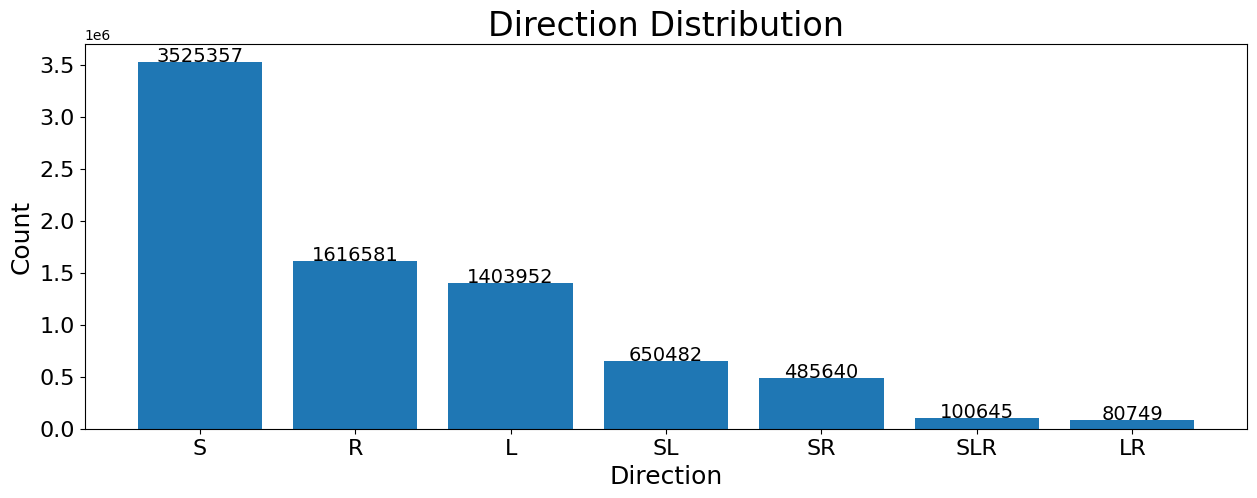

In [38]:
direction_df = pd.DataFrame(df['Direction'].value_counts())
direction_df.columns = ['Count']
direction_df.index.name = 'Direction'
plt.figure(figsize=(15,5))
plt.bar(direction_df.index, direction_df['Count'])
plt.title('Direction Distribution', fontsize=24)
plt.xlabel('Direction', fontsize=18)
plt.ylabel('Count', fontsize=18)
for index, value in enumerate(direction_df['Count']):
    plt.text(index, value + 5000, str(value), ha='center', fontsize=14)
# plt.xticks(fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.show()
